# Time Series forecasting with Facebook Prophet

## What you'll learn in this course

With Machine Learning comes very specific data: Time series. That type of data should be treated very specifically. In this course, you'll learn:

* How to handle Time Series data
* What are the common models
* Create time series forecasting with Prophet
* The model behind Prophet
* Include seasonality, holidays and other specific events in your forecast

## What are Time Series 🤔🤔

Simply put time series are data based on time. For example you can have:

* Sales forecast
* Spread of a virus over time
* Stock prices prediction
* Weather forecasting
* ...

## Models associated with Time Series 📈📈

When you are doing time series forecasting. You can use plenty different types of models. Among the most popular are:

* Moving averages
* Auto-correlations
* Autoregressive Integrated Moving Average (ARIMA)

## Facebook Prophet 🔮🔮

Prophet is an open source project used for Time Series Forecasting. Basically, Prophet rely on three components:

$y(t) = g(t) + s(t) + h(t) + \varepsilon_{t}$

where

$y(t)$ - forecast

$g(t)$ - trend

$s(t)$ - seasonality or periodical changes

$h(t)$ - holidays

$\varepsilon_{t}$ - Noise

We'll review each of these components in this course.


## Example with Finance Data

For the rest of the course, we'll be using financial data from Yahoo and its `yfinance` library

In [24]:
#!pip install pystan~=2.14
#!pip install prophet

In [1]:
#imports

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

import matplotlib.pyplot as plt
import yfinance as yf ##

import pandas as pd

from prophet import Prophet


In [ ]:
#!pip install -q yfinance

In [10]:
# Import the plotting library and data from stock AAPL

## get the data of the stock AAPL
data = yf.download("AAPL", "2017-01-01", "2021-12-31")
data

# Plot the close price of the AAPL


/var/folders/lw/9stf5nqd2kjgyfwhgwq8qs_w0000gn/T/ipykernel_61560/2016832314.py:4: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2017-01-03,26.796835,26.838363,26.476150,26.716087,115127600
2017-01-04,26.766842,26.879891,26.704551,26.727622,84472400
2017-01-05,26.902962,26.960639,26.718394,26.743772,88774400
2017-01-06,27.202887,27.260564,26.870665,26.942184,127007600
2017-01-09,27.452049,27.553562,27.209806,27.212112,134247600
...,...,...,...,...,...
2021-12-23,172.825394,173.384230,171.835192,172.403828,68356600
2021-12-27,176.796066,176.884299,173.599958,173.619555,74919600


In [11]:
# show data
## plot of the close price of AAPL
fig = px.line(x= data["Close"].index, y= data["Close"]["AAPL"])
fig.show()

Our goal is going to predict future stock prices of Apple Inc.

## Forecasting 🧙‍♂️🧙‍♂️

The best thing about Prophet is that it follows the same principles as `sklearn`. Making it very easy to use. Let's show a quick example.

First Prophet needs to receive a DataFrame with the:

* `ds` column corresponding to the time in YYYY-MM-DD format
* `y` column corresponding to your target variable

In [12]:
import pandas as pd

# Format a dataframe for Prophet where you need to have a 'ds' column for time and 'y' column for prediction
p_df = pd.DataFrame({
    "ds": data.index,
    "y": data["Open"]["AAPL"]
}).reset_index(drop=True)

p_df["ds"] = p_df["ds"].dt.tz_localize(None) ## removes timezone for compatibility with latest version of the library
p_df

,ds,y
0,2017-01-03,26.716087
1,2017-01-04,26.727622
2,2017-01-05,26.743772
3,2017-01-06,26.942184
4,2017-01-09,27.212112
...,...,...
1253,2021-12-23,172.403828
1254,2021-12-27,173.619555
1255,2021-12-28,176.629404
1256,2021-12-29,175.815677


Next, we'll instanciate a `Prophet` instance and `fit` it to our DataFrame

In [13]:
# instanciate Prophet

m = Prophet()
m.fit(p_df) ## fits the training data from 2017-2021

10:55:52 - cmdstanpy - INFO - Chain [1] start processing
10:55:53 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
# forecasting

future = m.make_future_dataframe(periods=365) ## let us forecast one year
future


,ds
0,2017-01-03
1,2017-01-04
2,2017-01-05
3,2017-01-06
4,2017-01-09
...,...
1618,2022-12-26
1619,2022-12-27
1620,2022-12-28
1621,2022-12-29


Let's make our predictions

In [15]:
# predictions
forecast = m.predict(future)
forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1618,2022-12-26,191.900754,169.566910,221.665893,165.396328,216.764952,5.312596,5.312596,5.312596,-0.496489,-0.496489,-0.496489,5.809085,5.809085,5.809085,0.0,0.0,0.0,197.213350
1619,2022-12-27,192.000134,170.226739,222.994660,165.397292,216.947598,5.551315,5.551315,5.551315,-0.111716,-0.111716,-0.111716,5.663031,5.663031,5.663031,0.0,0.0,0.0,197.551450
1620,2022-12-28,192.099514,170.692687,224.306400,165.397507,217.131380,5.414830,5.414830,5.414830,-0.078416,-0.078416,-0.078416,5.493246,5.493246,5.493246,0.0,0.0,0.0,197.514345
1621,2022-12-29,192.198895,169.567453,223.772030,165.468422,217.404533,5.161851,5.161851,5.161851,-0.141380,-0.141380,-0.141380,5.303231,5.303231,5.303231,0.0,0.0,0.0,197.360746
1622,2022-12-30,192.298275,169.347818,223.095901,165.414130,217.677685,4.734700,4.734700,4.734700,-0.362192,-0.362192,-0.362192,5.096892,5.096892,5.096892,0.0,0.0,0.0,197.032975


And finally plot the results with plotly

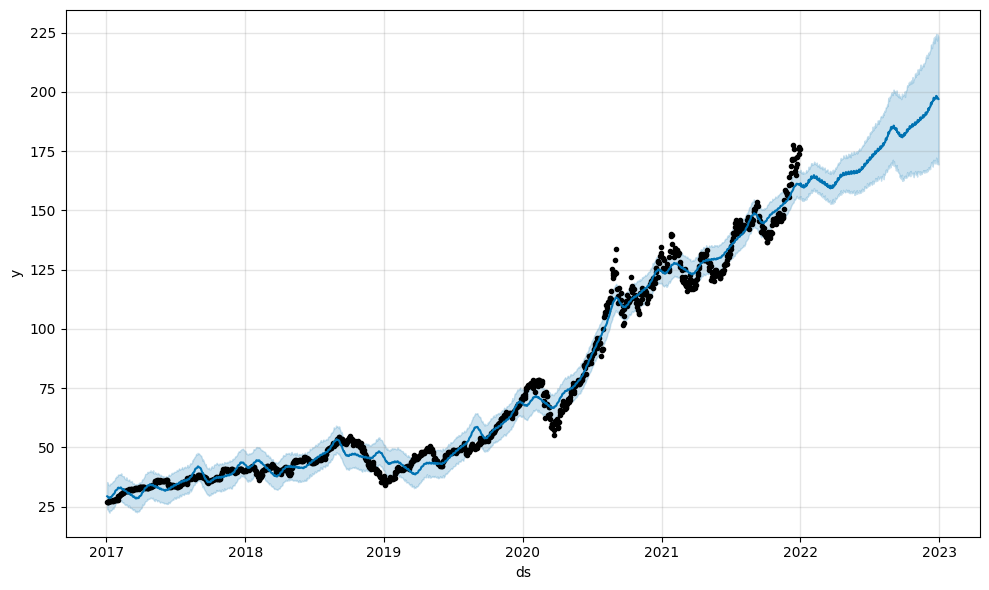

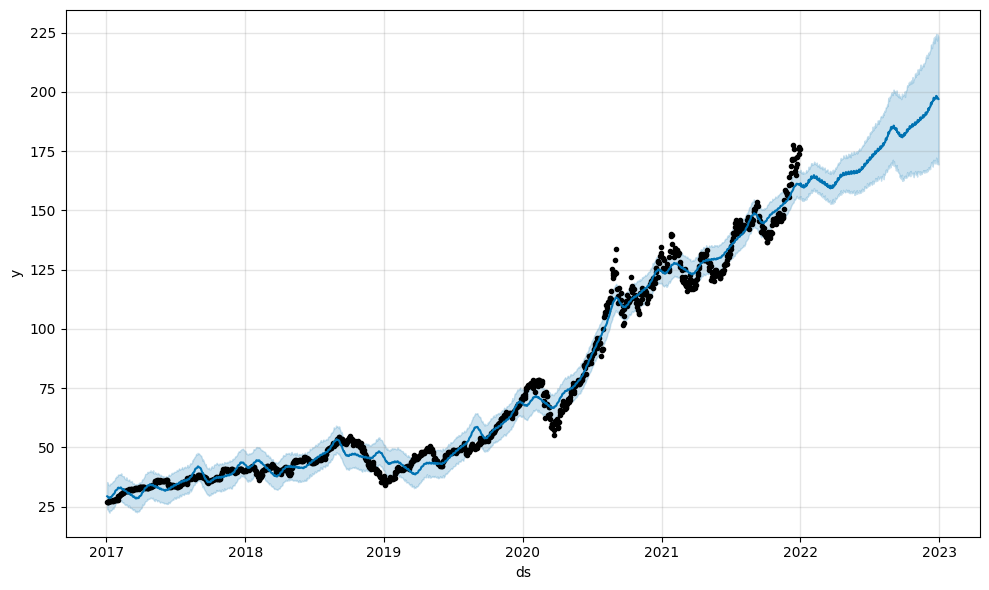

In [16]:
#plot
m.plot(forecast)

You can also plot each components of your trend. So that you can see the seasonality.

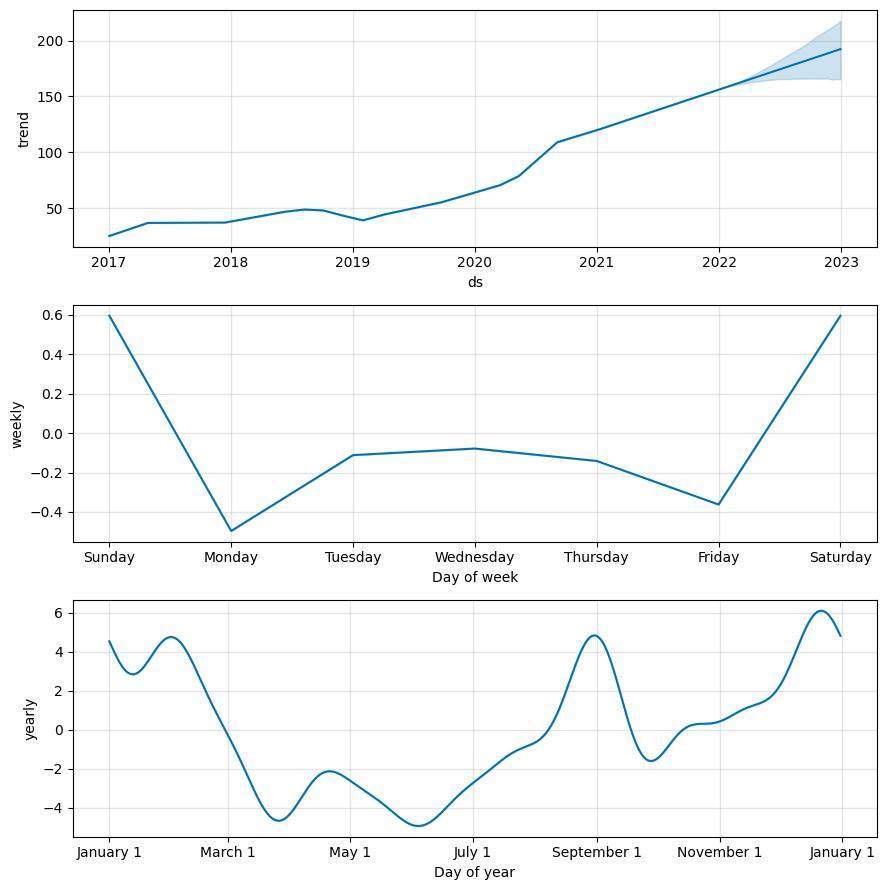

In [17]:
# components

fig2 = m.plot_components(forecast)

## Handle Seasonality

One very cool feature that you can use with Prophet is to add seasonality. For example, you can add country holidays.

In [27]:
# handle seasonality

m = Prophet()
m.add_country_holidays(country_name="US")
m.fit(p_df)

11:06:04 - cmdstanpy - INFO - Chain [1] start processing
11:06:04 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
# holidays
m.train_holiday_names

0                                      New Year's Day
1                           New Year's Day (observed)
2                                        Memorial Day
3                                    Independence Day
4                                           Labor Day
5                                        Veterans Day
6                             Veterans Day (observed)
7                                    Thanksgiving Day
8                                       Christmas Day
9                          Martin Luther King Jr. Day
10                              Washington's Birthday
11                                       Columbus Day
12                        Independence Day (observed)
13               Juneteenth National Independence Day
14    Juneteenth National Independence Day (observed)
15                           Christmas Day (observed)
dtype: object

Check now its impact on your forecast

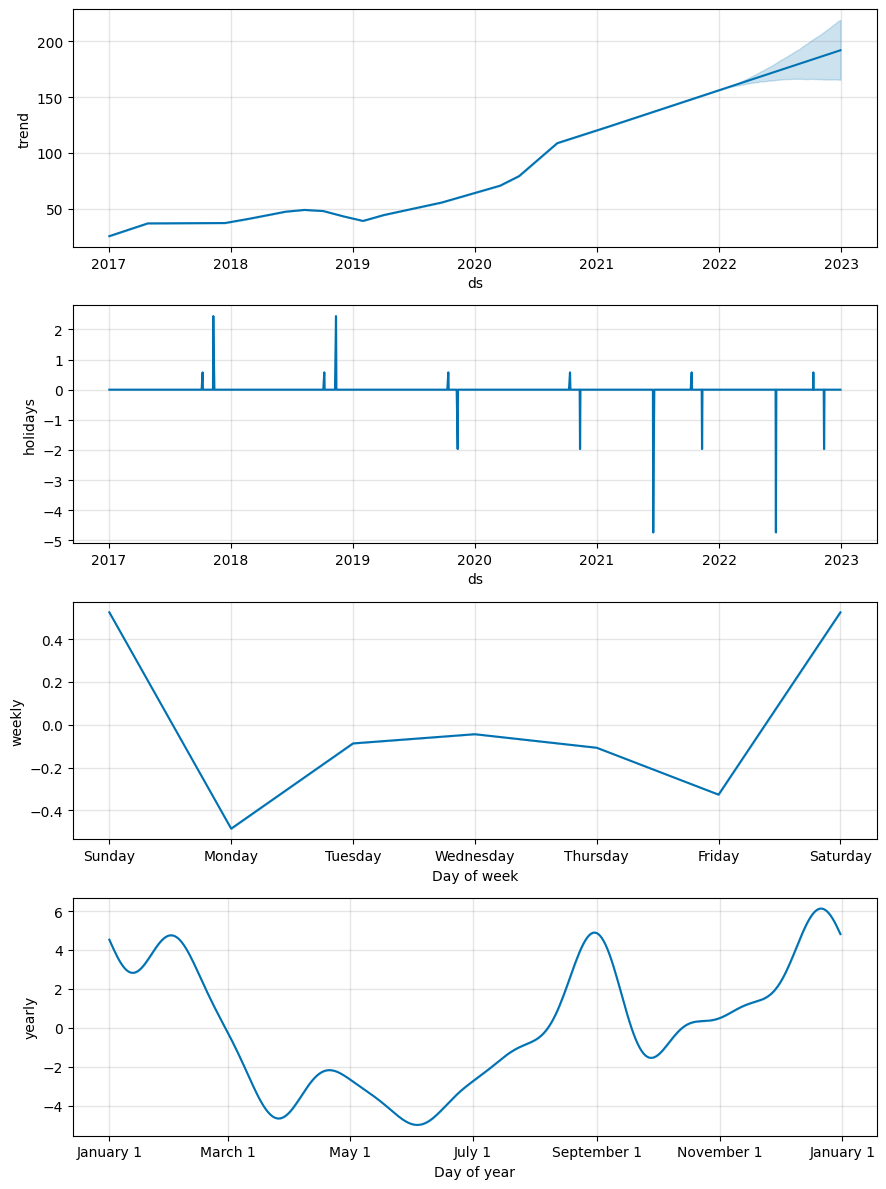

In [29]:
#impact
forecast = m.predict(future)
fig = m.plot_components(forecast)

You can also add manual holidays by providing a `holidays` DataFrame

In [12]:
# holidays dataframe

In [30]:
# new_holiday

new_holiday = pd.DataFrame({
    "holiday": "new_holiday",
    "ds": pd.to_datetime(["2017-11-26", "2018-11-26", "2019-11-26"]),
    "lower_window": 0,
    "upper_window":1
})

m = Prophet(holidays=new_holiday)
m.fit(p_df)


11:09:12 - cmdstanpy - INFO - Chain [1] start processing
11:09:12 - cmdstanpy - INFO - Chain [1] done processing


In [31]:
# show thanksgiving
new_holiday

,holiday,ds,lower_window,upper_window
0,new_holiday,2017-11-26,0,1
1,new_holiday,2018-11-26,0,1
2,new_holiday,2019-11-26,0,1


Let's check the impact of a holiday simply by checking if we have positive or negative correlations in our prediction dataframe.

In [32]:
# impact on future

forecast = m.predict(future)

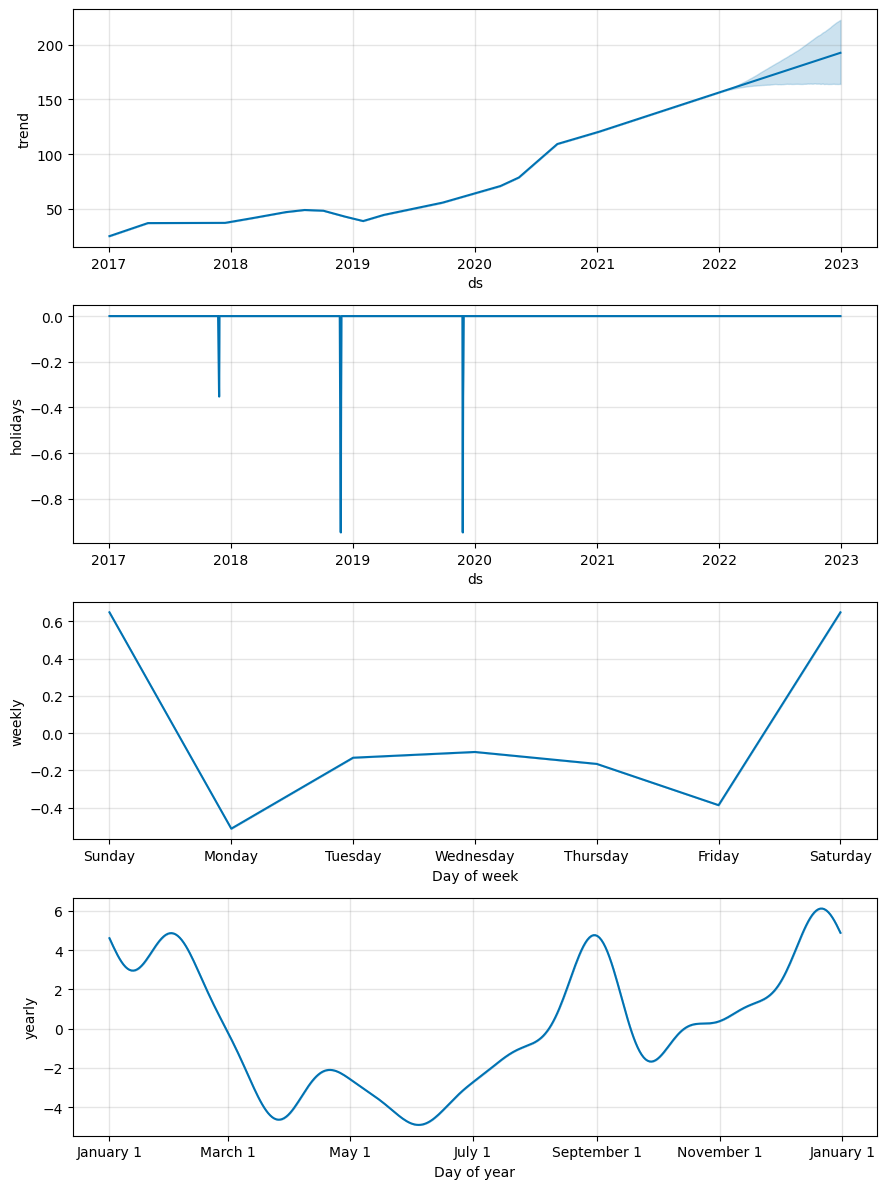

In [33]:
fig = m.plot_components(forecast)

In [ ]:
#value counts


## Multi-variate forecasting

Sometimes, you might want to create forecast not only with times but with also other variables. Prophet calls it Regressors. To add a regressor, you can simply do:

In [36]:
# Get the data of Microsoft Stock

msft = yf.download("MSFT", "2017-01-01", "2021-12-31")

# Preprocess the data
msft = pd.DataFrame({"ds": msft.index,
                     "msft_stock_price": msft["Open"]["MSFT"]}).reset_index(drop=True)

msft

/var/folders/lw/9stf5nqd2kjgyfwhgwq8qs_w0000gn/T/ipykernel_61560/2085833578.py:3: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


,ds,msft_stock_price
0,2017-01-03,56.686998
1,2017-01-04,56.407118
2,2017-01-05,56.145305
3,2017-01-06,56.244618
4,2017-01-09,56.659914
...,...,...
1253,2021-12-23,323.096049
1254,2021-12-27,325.727486
1255,2021-12-28,333.194327
1256,2021-12-29,331.398040


In [37]:
p_df["msft_stock_price"] = msft["msft_stock_price"]
p_df

,ds,y,msft_stock_price
0,2017-01-03,26.716087,56.686998
1,2017-01-04,26.727622,56.407118
2,2017-01-05,26.743772,56.145305
3,2017-01-06,26.942184,56.244618
4,2017-01-09,27.212112,56.659914
...,...,...,...
1253,2021-12-23,172.403828,323.096049
1254,2021-12-27,173.619555,325.727486
1255,2021-12-28,176.629404,333.194327
1256,2021-12-29,175.815677,331.398040


Let's incorporate this column in our DataFrame

In [ ]:
# dataframe
## this is done

In [38]:
# create regressor

m = Prophet()
m.add_regressor("msft_stock_price")

However, once you added a regressor, you absolutely need to have it in your train set AND in your predictions. Therefore, let's split our dataset

In [40]:
# Train_test_split
train_size = int(0.8 * len(p_df))

X_train = p_df.iloc[:train_size, :]
X_test = p_df.iloc[train_size:, :]

X_test


,ds,y,msft_stock_price
1006,2020-12-31,130.647028,213.478483
1007,2021-01-04,130.101348,214.277682
1008,2021-01-05,125.589894,209.203116
1009,2021-01-06,124.449854,204.301871
1010,2021-01-07,125.073488,206.102523
...,...,...,...
1253,2021-12-23,172.403828,323.096049
1254,2021-12-27,173.619555,325.727486
1255,2021-12-28,176.629404,333.194327
1256,2021-12-29,175.815677,331.398040


In [41]:
# fit the model

m.fit(X_train)

11:18:54 - cmdstanpy - INFO - Chain [1] start processing
11:18:54 - cmdstanpy - INFO - Chain [1] done processing


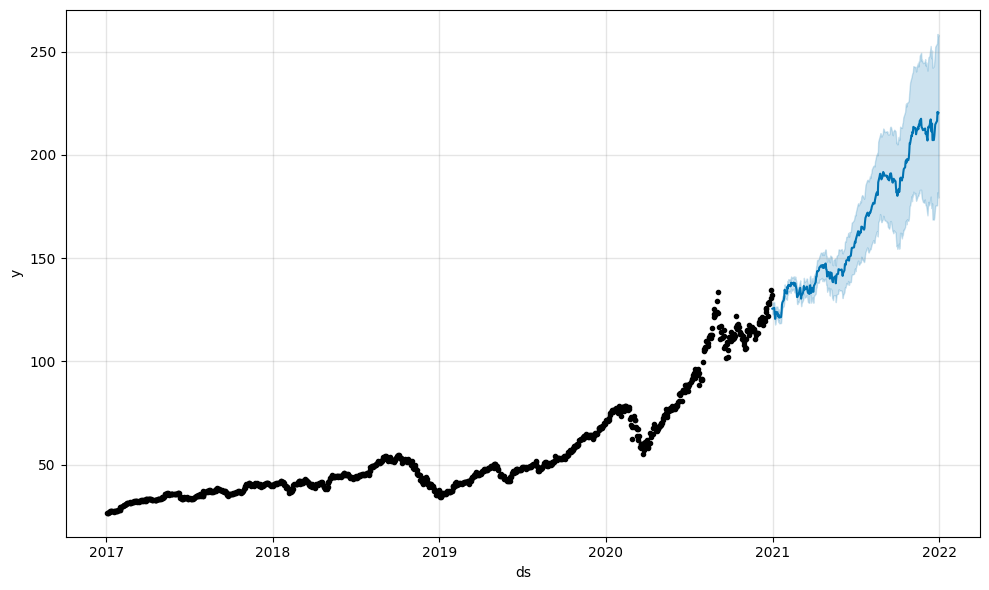

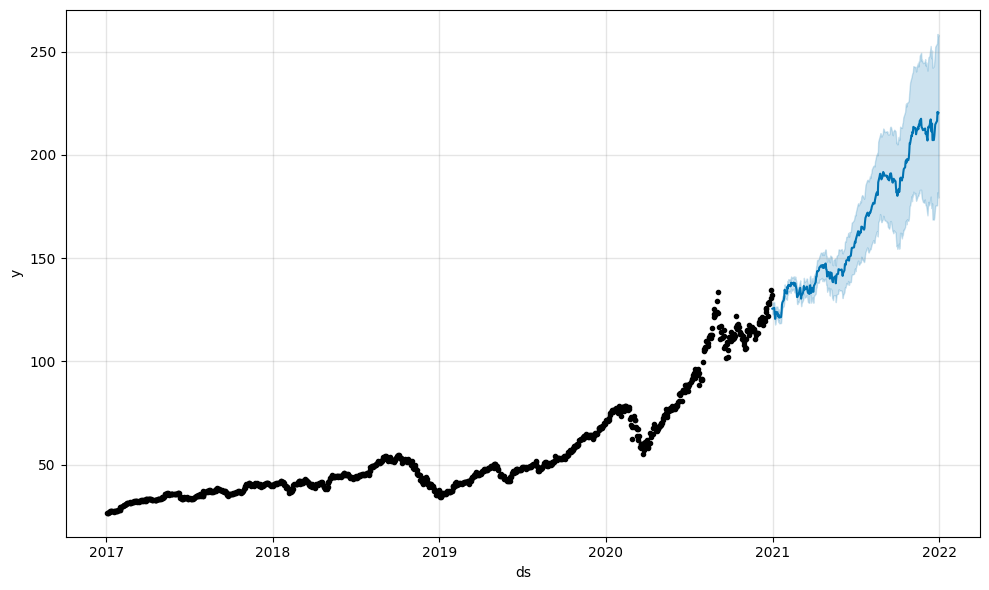

In [42]:
# Forecast
forecast = m.predict(X_test)
# Viz
m.plot(forecast)


In [43]:
# forecast the future

future = m.make_future_dataframe(periods=1)
future

,ds
0,2017-01-03
1,2017-01-04
2,2017-01-05
3,2017-01-06
4,2017-01-09
...,...
1002,2020-12-24
1003,2020-12-28
1004,2020-12-29
1005,2020-12-30


In [44]:
# visualise it

fig = px.scatter(p_df, x = "ds", y = "y")
fig.add_trace(px.line(forecast, x="ds", y="yhat").data[0])
fig['data'][1]['line']['color']="#4BE8E0"
fig.show() 

## Resources

* [Seasonality, Holiday Effects, And Regressors](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors)
* [Forecasting at Scale](https://peerj.com/preprints/3190/)
* [Introduction to Time Series Analysis](https://www.itl.nist.gov/div898/handbook/pmc/section4/pmc4.htm)
* [Time Series](https://en.wikipedia.org/wiki/Time_series#:~:text=A%20time%20series%20is%20a,sequence%20of%20discrete%2Dtime%20data.)